# Imtiaz Mahmud

# MileStone1 - NYC Yellow Taxi - March 1 - 3, 2023.</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
x = pd.read_csv("Yellow_Taxi_March_1-3.csv")
x

/usr/local/lib/python3.4/site-packages/IPython/core/interactiveshell.py:2785: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,03/01/2023 12:00:00 AM,03/01/2023 12:28:03 AM,1.0,12.77,1.0,N,138,87,1,51.30,6.00,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,03/01/2023 12:00:00 AM,03/01/2023 12:00:00 AM,3.0,6.22,1.0,N,162,13,2,29.60,0.00,0.5,0.00,0.00,1.0,33.60,2.5,0.00
2,2,03/01/2023 12:00:00 AM,03/01/2023 12:15:00 AM,NaN,3.83,NaN,NaN,68,238,0,18.14,0.00,0.5,4.43,0.00,1.0,26.57,NaN,NaN
3,2,03/01/2023 12:00:01 AM,03/01/2023 12:25:17 AM,1.0,13.93,1.0,N,132,155,1,54.10,1.00,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,03/01/2023 12:00:05 AM,03/01/2023 12:14:11 AM,2.0,2.9,1.0,N,234,13,1,16.30,1.00,0.5,3.00,0.00,1.0,24.30,2.5,0.00
5,2,03/01/2023 12:00:06 AM,03/01/2023 12:12:05 AM,1.0,2.95,1.0,N,158,163,1,15.60,1.00,0.5,4.12,0.00,1.0,24.72,2.5,0.00
6,2,03/01/2023 12:00:08 AM,03/01/2023 12:19:59 AM,1.0,3.8,1.0,N,148,230,1,22.60,1.00,0.5,5.52,0.00,1.0,33.12,2.5,0.00
7,2,03/01/2023 12:00:09 AM,03/01/2023 12:08:44 AM,1.0,1.89,1.0,N,163,236,1,11.40,1.00,0.5,4.92,0.00,1.0,21.32,2.5,0.00
8,2,03/01/2023 12:00:10 AM,03/01/2023 12:04:49 AM,1.0,2.06,1.0,N,170,141,2,10.00,1.00,0.5,0.00,0.00,1.0,15.00,2.5,0.00
9,2,03/01/2023 12:00:10 AM,03/01/2023 12:06:58 AM,1.0,2.16,1.0,N,239,24,2,10.70,1.00,0.5,0.00,0.00,1.0,15.70,2.5,0.00


### About the Date: 

In [3]:
x.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance             object
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
airport_fee              float64
dtype: object

In [4]:
x.tail(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
234239,1,03/02/2023 11:59:59 PM,03/03/2023 12:08:10 AM,1.0,1,1.0,N,79,113,1,7.90,3.50,0.5,1.00,0.00,1.0,13.90,2.5,0.00
234240,2,03/02/2023 11:59:59 PM,03/03/2023 12:27:50 AM,NaN,12.49,NaN,NaN,88,223,0,44.87,0.00,0.5,4.89,0.00,1.0,53.76,NaN,NaN
234241,1,03/03/2023 12:00:00 AM,03/03/2023 12:24:02 AM,1.0,8.4,1.0,N,138,24,1,35.90,7.25,0.5,5.00,6.55,1.0,56.20,0.0,1.25
234242,2,03/03/2023 12:00:00 AM,03/03/2023 12:04:39 AM,2.0,0.56,1.0,N,114,158,1,5.80,1.00,0.5,2.16,0.00,1.0,12.96,2.5,0.00
234243,2,03/03/2023 12:00:00 AM,03/03/2023 12:22:00 AM,NaN,5.71,NaN,NaN,79,238,0,24.47,0.00,0.5,5.69,0.00,1.0,34.16,NaN,NaN


In [5]:
x['tpep_pickup_datetime'] = pd.to_datetime(x['tpep_pickup_datetime'])
x['tpep_dropoff_datetime'] = pd.to_datetime(x['tpep_dropoff_datetime'])
x.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                    object
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [6]:
dup_filter = x.duplicated()
x[dup_filter]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [7]:
x.describe()

,VendorID,passenger_count,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,234244.000000,228205.000000,228205.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,228205.000000,228205.000000
mean,1.721282,1.295287,1.662667,167.495748,165.808588,1.172786,18.538090,1.763517,0.488725,3.497108,0.518409,0.982311,27.522062,2.287340,0.096010
std,0.461507,0.849248,7.671498,62.661207,68.657427,0.516893,17.241348,1.867576,0.097627,3.818645,2.044371,0.182196,21.664501,0.754667,0.337354
min,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-229.800000,-7.500000,-0.500000,-2.170000,-27.850000,-1.000000,-252.850000,-2.500000,-1.250000
25%,1.000000,1.000000,1.000000,132.000000,125.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,16.000000,2.500000,0.000000
50%,2.000000,1.000000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.900000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,1.000000,1.000000,234.000000,234.000000,1.000000,20.500000,2.500000,0.500000,4.340000,0.000000,1.000000,29.400000,2.500000,0.000000
max,6.000000,6.000000,99.000000,265.000000,265.000000,4.000000,446.100000,11.250000,4.000000,237.150000,177.000000,1.000000,482.450000,2.500000,1.250000


In [8]:
missing_rows = x.isna().any(axis = 1)
missing_rows.head()

0    False
1    False
2     True
3    False
4    False
dtype: bool

In [9]:
missing_rows.sum()

6039

In [10]:
ax =x[~missing_rows]
ax.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,29.6,0.0,0.5,0.00,0.00,1.0,33.60,2.5,0.00
3,2,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,1.0,N,132,155,1,54.1,1.0,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.9,1.0,N,234,13,1,16.3,1.0,0.5,3.00,0.00,1.0,24.30,2.5,0.00
5,2,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,1.0,N,158,163,1,15.6,1.0,0.5,4.12,0.00,1.0,24.72,2.5,0.00


In [11]:
len(ax)

228205

In [12]:
len(x)

234244

In [13]:
234244 - 228205

6039

In [15]:
abc = ax["total_amount"] >= 0
abc.value_counts()

True     226322
False      1883
Name: total_amount, dtype: int64

# No Duplicated Data Found...only 6039 missing rows removed. The clean data has 228205 rows....

In [46]:
abc.head(5)

0    True
1    True
3    True
4    True
5    True
Name: total_amount, dtype: bool

Text(0,0.5,'Number of Rides')

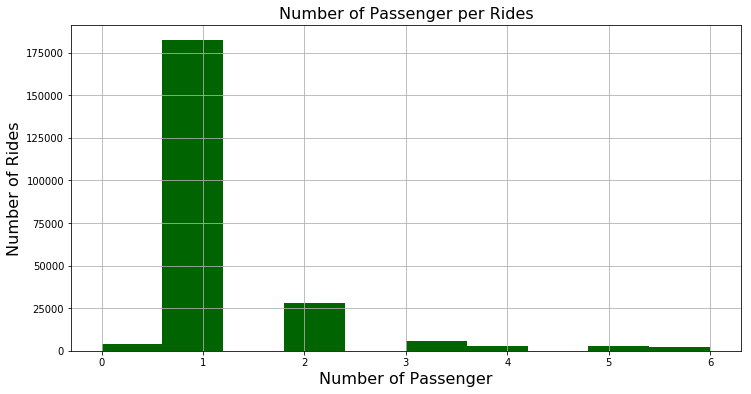

In [17]:
plt.figure(figsize=(12, 6))
ax["passenger_count"].hist(color = "darkgreen",)
plt.title("Number of Passenger per Rides",fontsize=16)
plt.xlabel("Number of Passenger", fontsize=16)
plt.ylabel("Number of Rides", fontsize=16)

In [18]:
ax.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,29.6,0.0,0.5,0.00,0.00,1.0,33.60,2.5,0.00
3,2,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,1.0,N,132,155,1,54.1,1.0,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.9,1.0,N,234,13,1,16.3,1.0,0.5,3.00,0.00,1.0,24.30,2.5,0.00
5,2,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,1.0,N,158,163,1,15.6,1.0,0.5,4.12,0.00,1.0,24.72,2.5,0.00


In [19]:
ax[["trip_distance", "tip_amount"]].dtypes

trip_distance     object
tip_amount       float64
dtype: object

In [20]:
ax["trip_distance"] = ax["trip_distance"].str.replace(",","")

ax["trip_distance"] = ax["trip_distance"].astype(float)


/usr/local/lib/python3.4/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.4/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [21]:
ax[["trip_distance", "tip_amount"]].dtypes

trip_distance    float64
tip_amount       float64
dtype: object

In [22]:
ax["tpep_pickup_datetime"] = pd.to_datetime(new_x["tpep_pickup_datetime"])

NameError: name 'new_x' is not defined

In [23]:
def maxx(x):
    if x > 0:
        return 1
    else:
        return 0

In [24]:
ax["toll_x"] = ax["tolls_amount"].apply(maxx)

/usr/local/lib/python3.4/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


Text(0,0.5,'Number of Trips')

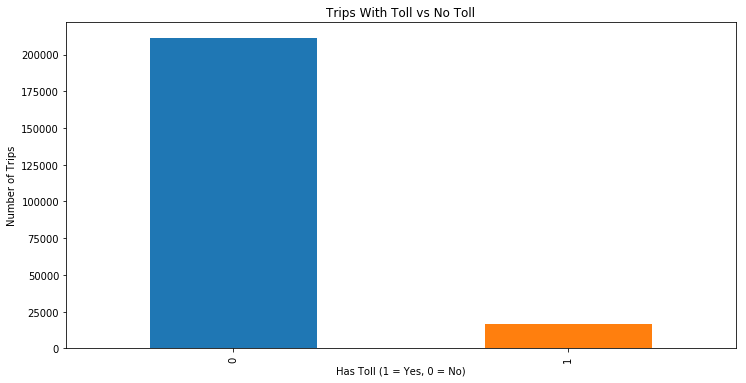

In [25]:
plt.figure(figsize=(12, 6))

tx = ax["toll_x"].value_counts()

tx.plot(kind="bar")

plt.title("Trips With Toll vs No Toll")
plt.xlabel("Has Toll (1 = Yes, 0 = No)")
plt.ylabel("Number of Trips")


In [26]:
ax.head(1)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,toll_x
0,2,2023-03-01,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.0,6.55,1.0,74.1,2.5,1.25,1


In [27]:
def rrr(x):
    if x > 0:
        return 1
    else:
        return 0

In [28]:
ax["c_x"] =ax["congestion_surcharge"].apply(rrr)

/usr/local/lib/python3.4/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


Text(0.5,0,'Number of Rides')

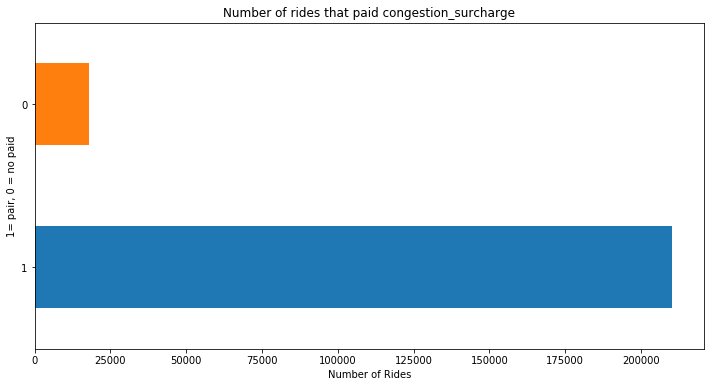

In [29]:
plt.figure(figsize=(12, 6))

yellow = ax["c_x"].value_counts()
yellow.plot(kind = "barh")
plt.title("Number of rides that paid congestion_surcharge")
plt.ylabel("1= pair, 0 = no paid")
plt.xlabel("Number of Rides")

Text(0.5,0,'Type of Paynment')

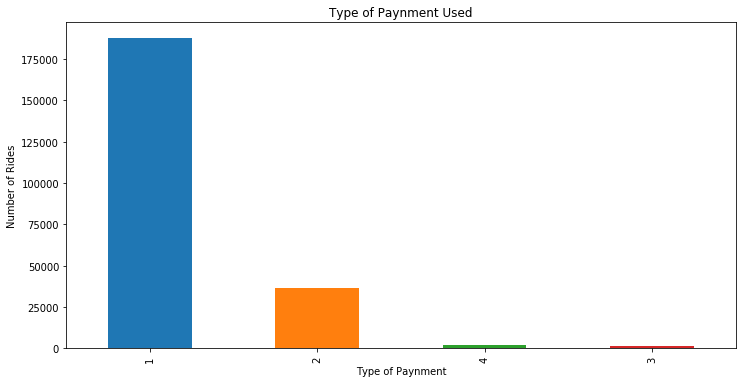

In [47]:
plt.figure(figsize=(12, 6))

pymn = ax["payment_type"].value_counts()
pymn.plot(kind = "bar")
plt.title("Type of Paynment Used")
plt.ylabel("Number of Rides")
plt.xlabel("Type of Paynment")

Text(0,0.5,'Average Total Amount ($)')

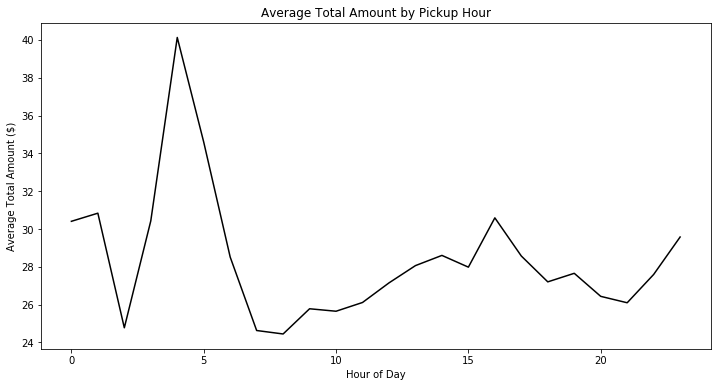

In [34]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_pickup_datetime"].dt.hour)["total_amount"].mean()
aaa.plot(kind="line", color = "black")
plt.title("Average Total Amount by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Amount ($)")

In [32]:
ax.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,toll_x,c_x
0,2,2023-03-01,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,...,6.0,0.5,5.0,6.55,1.0,74.1,2.5,1.25,1,1
1,2,2023-03-01,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,...,0.0,0.5,0.0,0.00,1.0,33.6,2.5,0.00,0,1


Text(0,0.5,'Average Total Tip Amount ($)')

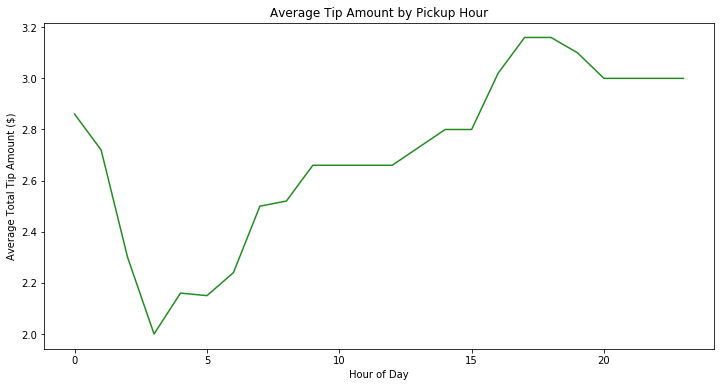

In [33]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_pickup_datetime"].dt.hour)["tip_amount"].median()
aaa.plot(kind="line", color = "forestgreen")
plt.title("Average Tip Amount by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Tip Amount ($)")

Text(0,0.5,'Average Total Amount ($)')

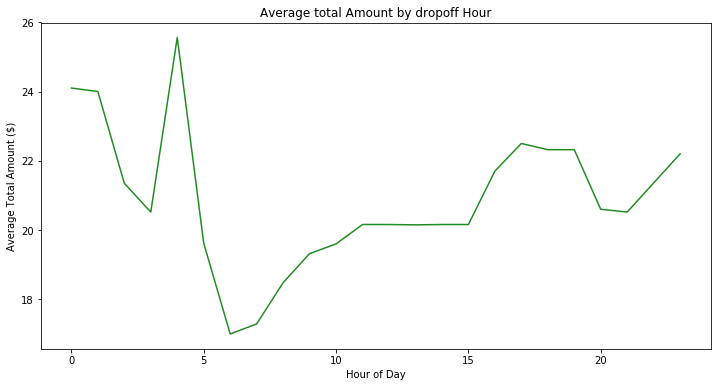

In [41]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_dropoff_datetime"].dt.hour)["total_amount"].median()
aaa.plot(kind="line", color = "forestgreen")
plt.title("Average total Amount by dropoff Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Amount ($)")